# Part one — Prediction: two alarms that pay for themselves 🍺

**Goal.** Build the whole brewery story in one place — create the data, fit the checks,
break things on purpose, and watch the diagnosis work. Everything you see is made by this
notebook itself, from the first data point to the last verdict.

*Companion notebook to the article **A Window into World Models: The Next Generation of
AI**. Everything is simulated — that is what lets us grade every answer — seeded, and it
runs top-to-bottom on Google Colab.*

Picture a 400 hL tank of lager, fermenting for about 42 hours. One reaction drives it all —
**C₆H₁₂O₆ → 2 C₂H₅OH + 2 CO₂** — and the quantities that decide the beer's quality (how
much sugar is left, how much alcohol has formed, how much yeast is still working) stay
**hidden** during the run. The control panel shows only four instruments: density, CO₂
flow, the cooling valve, and haze.

Here is the plan. We create five normal batches and learn two simple checks from them.
Then we break things on purpose, twice:

1. **a tank fault** — the yeast settles out early;
2. **an instrument fault** — the densitometer slowly drifts.

The point is not that these simple checks *understand* the tank. The point is to see how
much prediction alone can do — before Part two asks the harder question: can a method
recover the hidden state itself?

In [1]:
# Colab standard runtime is enough.
import numpy as np, warnings, itertools
import pandas as pd
from pathlib import Path
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
GOOD_C, BAD_C, GREY = "#1a7f37", "#b3261e", "#8a91a0"

OUT = Path("generated_data")
OUT.mkdir(exist_ok=True)
print("Generated files will be written to:", OUT.resolve())


Generated files will be written to: /sessions/trusting-intelligent-franklin/mnt/outputs/nbrun/generated_data


## 1 · Create the simulated brewery

Everything starts here. The next cell is the physical simulator, written out in full:
yeast that grows and slows as ethanol builds up (Monod kinetics), a warm tank fermenting
faster than a cold one (the Q10 law), a controller opening the cooling valve, yeast slowly
settling out (that is the haze signal), and realistic noise on every instrument.

`brew()` produces one complete 42-hour tank record. Its optional switches let us break the
tank or break a meter later, on purpose. The five `GOOD` settings make the five normal
batches we will learn from.

In [2]:
N_ROWS, DT_S = 1000, 150.0        # 2.5 min -> 41.7 h
HORIZON = 24                      # rows = 1 h ahead
LAGS = [0, 12, 48, 96]           # and 0.5, 2, 4 h before that

V = 40.0                          # m3 = 400 hL
S0_NOM = 95.0                     # g/L fermentable sugar (about 9.2 Plato)
X0_NOM = 1.10                     # g/L yeast pitched
XMAX = 6.4
MU_MAX, KS_M = 0.115, 2.0
KI_ETH = 68.0
YXS_G, M_S = 0.145, 0.042
YES, YCS = 0.484, 0.463           # g ethanol / g CO2 per g sugar
DH, MW_S = 100000.0, 180.16
RHO_W = 1000.0
K_RHO_S, K_RHO_E = 0.386, 0.371
VM = 0.02445
T_SET, T_GLY = 12.0, -4.0
UA_MAX = 1250.0                   # W/K, fully open glycol valve
RHO_CP = 1040.0 * 3900.0          # J per m3 per K
KP = 0.55
TURB_0, TURB_X = 120.0, 620.0
E_FLOC, W_FLOC = 17.0, 2.8
Q10 = 2.20                        # yeast: how much faster per 10 C

CHAN = ["rho", "QCO2", "Cool", "Turb"]
UNITS = {"rho": "kg/m3", "QCO2": "m3/h", "Cool": "%", "Turb": "NTU"}
NAME = {"rho": "density", "QCO2": "CO2 flow", "Cool": "cooling",
        "Turb": "haze"}
NOISE = {"rho": 0.05, "QCO2": 0.15, "Cool": 0.20, "Turb": 15.0}


def plato(rho):
    """Density in kg/m3 -> degrees Plato, the unit a brewer actually uses."""
    sg = np.asarray(rho) / 998.2
    return 259.0 - 259.0 / sg


def brew(seed=0, S0=S0_NOM, X0=X0_NOM, glycol_fails_at=None,
         glycol_left=0.12, meter_drifts_at=None, drift_rate=0.10,
         yeast_drops_at=None, drop_k=0.10):
    """One tank. `glycol_fails_at` and `meter_drifts_at` are hours."""
    h = DT_S / 3600.0
    t = np.arange(N_ROWS) * h
    S, X, T = S0, X0, T_SET
    Ss, Xs, Rs, Ts, Cs = [], [], [], [], []
    for i in range(N_ROWS):
        E = (S0 - S) * YES
        # warm beer ferments faster -- this is what makes a cooling fault
        # change the product and not just the panel
        fT = Q10 ** ((T - T_SET) / 10.0)
        mu = (MU_MAX * fT * S / (KS_M + S) * max(0.0, 1.0 - E / KI_ETH)
              * max(0.0, 1.0 - X / XMAX))
        rate = (mu / YXS_G + M_S * fT) * X * (S / (KS_M + S))
        Ss.append(S); Xs.append(X); Rs.append(rate); Ts.append(T)
        valve = float(np.clip(KP * (T - T_SET) * 100.0, 0.0, 100.0))
        Cs.append(valve)
        ua = UA_MAX
        if glycol_fails_at is not None and t[i] >= glycol_fails_at:
            ua = UA_MAX * glycol_left      # the glycol side is starved
        q_gen = DH * rate / MW_S * V * 1000.0 / 3600.0
        q_rem = ua * valve / 100.0 * (T - T_GLY)
        T += (q_gen - q_rem) / (RHO_CP * V) * DT_S
        S = max(S - rate * h, 0.0)
        # the yeast starts leaving suspension early. Nothing on the panel
        # caused this and nothing on the panel explains it.
        ks = (drop_k if (yeast_drops_at is not None
                         and t[i] >= yeast_drops_at) else 0.0)
        X = min(max(X + (mu - ks) * X * h, 0.02), XMAX)
    S = np.array(Ss); X = np.array(Xs); rate = np.array(Rs)
    T = np.array(Ts); Cool = np.array(Cs)
    E = (S0 - S) * YES
    X_susp = X / (1.0 + np.exp((E - E_FLOC) / W_FLOC))
    out = dict(t=t, T=T, Sugar=S, Ethanol=E, CO2=(S0 - S) * YCS, Yeast=X,
               rate=rate,
               rho=RHO_W + K_RHO_S * S - K_RHO_E * E,
               QCO2=rate * V * 1000.0 / 44.01 * VM,
               Cool=Cool, Turb=TURB_0 + TURB_X * X_susp)
    if meter_drifts_at is not None:
        d = np.where(t >= meter_drifts_at, (t - meter_drifts_at) * drift_rate,
                     0.0)
        out["rho"] = out["rho"] + d
    rs = np.random.RandomState(seed)
    for c in CHAN:
        out[c] = out[c] + NOISE[c] * rs.randn(N_ROWS)
    out["Cool"] = np.clip(out["Cool"], 0.0, 100.0)
    return out


# five good tanks: ordinary variation in pitch and wort, all sellable
GOOD = [dict(seed=101, S0=95.0, X0=1.10),
        dict(seed=102, S0=96.4, X0=1.05),
        dict(seed=103, S0=93.8, X0=1.16),
        dict(seed=104, S0=95.7, X0=1.12),
        dict(seed=105, S0=94.5, X0=1.08)]


def good_tanks():
    return [brew(**g) for g in GOOD]

In [3]:
tanks = good_tanks()                       # five good production records
d0 = tanks[0]
print("hours:", round(float(d0['t'][-1]), 1), "| rows per tank:", len(d0['t']))
print("gravity: %.2f -> %.2f °P   alcohol at end: %.2f %% ABV"
      % (plato(d0['rho'][0]), plato(d0['rho'][-1]), d0['Ethanol'][-1] / 7.94))

hours: 41.6 | rows per tank: 1000
gravity: 9.64 -> 4.14 °P   alcohol at end: 2.40 % ABV


In [4]:
# Turn the five simulated good tanks into visible datasets.
# These CSV files are outputs of this notebook, not inputs.

def tank_frame(d):
    cols = ["t", "T", "Sugar", "Ethanol", "CO2", "Yeast", "rate"] + CHAN
    return pd.DataFrame({c: np.asarray(d[c]) for c in cols})

good_files = []
for i, d in enumerate(tanks, start=1):
    path = OUT / f"good_tank_{i}.csv"
    tank_frame(d).to_csv(path, index=False)
    good_files.append(path)

print("Created five good datasets:")
for pth in good_files:
    print(" -", pth)

display(tank_frame(tanks[0]).head())


Created five good datasets:
 - generated_data/good_tank_1.csv
 - generated_data/good_tank_2.csv
 - generated_data/good_tank_3.csv
 - generated_data/good_tank_4.csv
 - generated_data/good_tank_5.csv


,t,T,Sugar,Ethanol,CO2,Yeast,rate,rho,QCO2,Cool,Turb
0,0.000000,12.000000,95.000000,0.000000,0.000000,1.100000,0.738230,1036.805342,16.502850,0.000000,792.367960
1,0.041667,12.004209,94.969240,0.014888,0.014242,1.104275,0.740622,1036.684010,16.447041,0.464999,795.698390
2,0.083333,12.008390,94.938381,0.029824,0.028530,1.108563,0.743015,1036.680549,16.453754,0.643404,811.749322
3,0.125000,12.012541,94.907422,0.044808,0.042863,1.112866,0.745409,1036.642833,16.630283,0.676467,815.014541
4,0.166667,12.016664,94.876364,0.059840,0.057244,1.117181,0.747804,1036.632632,16.541519,0.874734,807.429204


## 2 · Check one — the golden curve

Take the good records and average them, instrument by instrument. The result is the
**golden curve**: the path a healthy ferment follows. The tolerance band around it comes
from the good tanks themselves — how far they naturally wandered, smoothed, with a floor at
3× the instrument noise and a safety factor of 1.6. Every gap is judged as a **one-hour
rolling average**, so one noisy sample can never set off an alarm.

In [5]:
def golden(tanks):
    """Mean curve per channel + smoothed time-varying tolerance."""
    prof, tol = {}, {}
    for c in CHAN:
        Y = np.vstack([np.asarray(d[c]) for d in tanks])
        mu = Y.mean(axis=0)
        dev = np.abs(Y - mu).max(axis=0)         # worst good-tank deviation
        # smooth over 2 h and pad: a new good tank may stray a bit further
        w = 48
        pad = np.convolve(dev, np.ones(w) / w, "same")
        tol[c] = 1.6 * np.maximum(pad, 3 * NOISE[c])
        prof[c] = mu
    return prof, tol


def time_check(prof, tol, d):
    """Rolling 1-h mean of |reading - golden| vs tolerance."""
    out = {}
    for c in CHAN:
        gap = np.asarray(d[c]) - prof[c]
        roll = np.convolve(gap, np.ones(K) / K, "same")
        bad = np.abs(roll) > tol[c]
        i = np.where(bad)[0]
        out[c] = dict(alarm=bool(len(i)),
                      first=float(d["t"][i[0]]) if len(i) else None,
                      worst=float(np.max(np.abs(roll) / tol[c])))
    return out

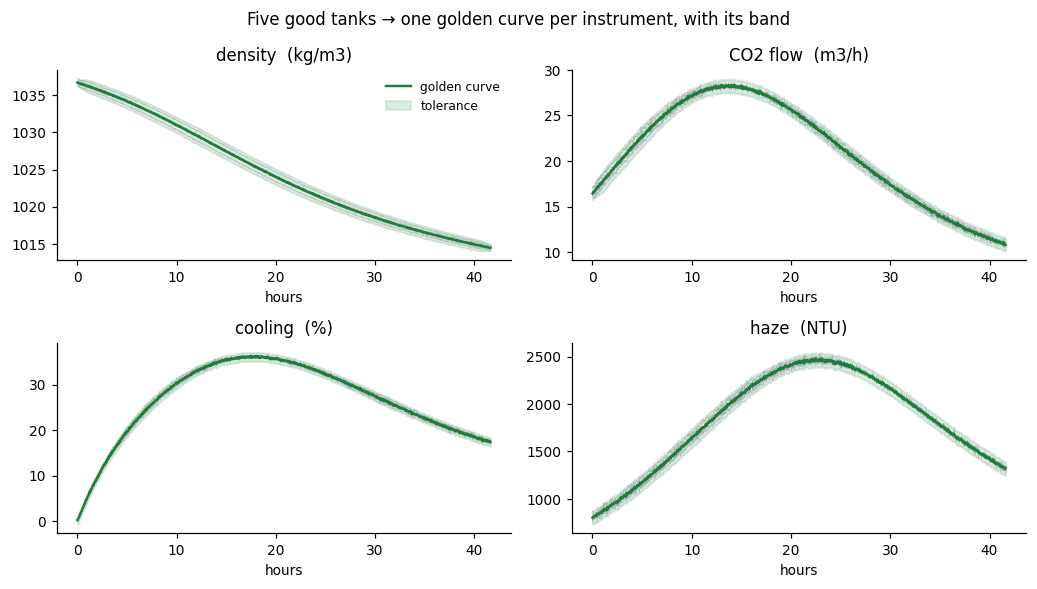

In [6]:
K = HORIZON                                  # 24 rows = 1 hour
prof, tol = golden(tanks)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.4))
for ax, c in zip(axes.ravel(), CHAN):
    t = d0["t"]
    for d in tanks:
        ax.plot(t, d[c], lw=.5, color=GREY, alpha=.5)
    ax.plot(t, prof[c], color=GOOD_C, lw=1.6, label="golden curve")
    ax.fill_between(t, prof[c] - tol[c], prof[c] + tol[c],
                    color=GOOD_C, alpha=.15, label="tolerance")
    ax.set_title(f"{NAME[c]}  ({UNITS[c]})"); ax.set_xlabel("hours")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Five good tanks → one golden curve per instrument, with its band")
fig.tight_layout(); plt.show()

## 3 · Check two — the instruments are not independent

The four instruments watch **one** reaction, so they cannot move independently. Plot
density against CO₂ and haze, and the readings do not fill the space — they settle onto a
plane. In plain words: if you know two of them, you nearly know the third. That dependence
is the engine of the second check.

density = 1.04 x CO2  -0.0070 x haze  +1015      R^2 = 0.95


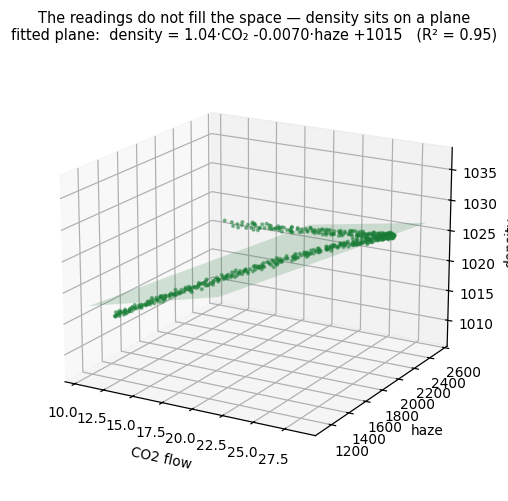

In [7]:
T0 = 120                                     # judge from hour 5 (valve pinned before)
rho_ = np.concatenate([np.asarray(d["rho"])[T0:] for d in tanks])
q_   = np.concatenate([np.asarray(d["QCO2"])[T0:] for d in tanks])
h_   = np.concatenate([np.asarray(d["Turb"])[T0:] for d in tanks])
A = np.c_[q_, h_, np.ones_like(q_)]
(a, b, c0), *_ = np.linalg.lstsq(A, rho_, rcond=None)
pred = A @ np.array([a, b, c0])
r2 = 1 - ((rho_ - pred)**2).sum() / ((rho_ - rho_.mean())**2).sum()
print(f"density = {a:.2f} x CO2  {b:+.4f} x haze  {c0:+.0f}      R^2 = {r2:.2f}")

from mpl_toolkits.mplot3d import Axes3D      # noqa
fig = plt.figure(figsize=(7.2, 5.2)); ax = fig.add_subplot(111, projection="3d")

# the fitted plane itself, drawn as a translucent surface through the cloud
qg = np.linspace(q_.min(), q_.max(), 24)
hg = np.linspace(h_.min(), h_.max(), 24)
Qm, Hm = np.meshgrid(qg, hg)
ax.plot_surface(Qm, Hm, a*Qm + b*Hm + c0, color=GOOD_C, alpha=0.18,
                edgecolor="none", zorder=1)

s = slice(None, None, 8)
ax.scatter(q_[s], h_[s], rho_[s], s=3, c=GOOD_C, alpha=.45, zorder=3)
ax.set_xlabel("CO2 flow"); ax.set_ylabel("haze"); ax.set_zlabel("density")
ax.set_title("The readings do not fill the space — density sits on a plane\n"
             f"fitted plane:  density = {a:.2f}\u00b7CO\u2082 {b:+.4f}\u00b7haze {c0:+.0f}   (R\u00b2 = {r2:.2f})",
             fontsize=9.5)
ax.view_init(elev=18, azim=-60)
plt.show()

So we go further and fit **every** instrument as a quadratic formula of the other three
(`fit_recon`). We also fit **leave-one-out** versions, where each instrument is rebuilt
from only two others. That second set is what lets us *name* a broken meter: a broken
instrument feeds its wrong reading into every formula that uses it, so the error spreads —
but the rebuilds that never touch it stay perfect.

`diagnose` is the whole decision rule, in three lines: nothing out → all clear; exactly one
instrument off its curve and disagreeing with its own rebuild, while the other three (with
the suspect removed) still agree → that instrument is broken; anything else → the tank is
wrong.

In [8]:
K = HORIZON
T0 = 120

def _feats(cols):
    """1, x_i, x_i^2, x_i*x_j  -- a quadratic surface, plain least squares."""
    n = cols[0].shape[0]
    f = [np.ones(n)]
    for i, c in enumerate(cols):
        f.append(c)
        f.append(c * c)
        for j in range(i + 1, len(cols)):
            f.append(c * cols[j])
    return np.column_stack(f)


def _fit(tanks, target, inputs):
    X = _feats([np.concatenate([np.asarray(d[c])[T0:] for d in tanks])
                for c in inputs])
    y = np.concatenate([np.asarray(d[target])[T0:] for d in tanks])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    worst = 0.0
    for d in tanks:
        p = _feats([np.asarray(d[c])[T0:] for c in inputs]) @ beta
        roll = np.convolve(np.asarray(d[target])[T0:] - p,
                           np.ones(K) / K, "same")
        worst = max(worst, float(np.max(np.abs(roll))))
    return beta, 1.5 * worst


def fit_recon(tanks):
    """Full rebuilds (from 3) and leave-one-out rebuilds (from 2)."""
    full, loo = {}, {}
    for tgt in CHAN:
        others = [c for c in CHAN if c != tgt]
        full[tgt] = (_fit(tanks, tgt, others), others)
        for skip in others:
            two = [c for c in others if c != skip]
            loo[(tgt, skip)] = (_fit(tanks, tgt, two), two)
    return full, loo


def _resid(d, target, inputs, beta):
    p = _feats([np.asarray(d[c])[T0:] for c in inputs]) @ beta
    return np.asarray(d[target])[T0:] - p


def recon_check(full, d):
    """Reading vs calculated-from-the-other-three, per channel."""
    out = {}
    for tgt, ((beta, sc), inputs) in full.items():
        roll = np.convolve(_resid(d, tgt, inputs, beta),
                           np.ones(K) / K, "same")
        i = np.where(np.abs(roll) > sc)[0]
        out[tgt] = dict(alarm=bool(len(i)),
                        first=float(d["t"][T0:][i[0]]) if len(i) else None,
                        worst=float(np.max(np.abs(roll) / sc)))
    return out


def avoid_check(loo, d, suspect):
    """Do the reconstructions that never touch `suspect` all hold?"""
    out = {}
    for tgt in CHAN:
        if tgt == suspect:
            continue
        (beta, sc), inputs = loo[(tgt, suspect)]
        roll = np.convolve(_resid(d, tgt, inputs, beta),
                           np.ones(K) / K, "same")
        out[tgt] = bool(np.any(np.abs(roll) > sc))
    return out


def diagnose(tc, rc, loo, d):
    t_bad = [c for c in CHAN if tc[c]["alarm"]]
    r_bad = [c for c in CHAN if rc[c]["alarm"]]
    if not t_bad and not r_bad:
        return "all clear", None
    if len(t_bad) == 1:
        c = t_bad[0]
        if rc[c]["alarm"] and not any(avoid_check(loo, d, c).values()):
            return "instrument fault", c
    return "tank fault", None

In [9]:
full, loo = fit_recon(tanks)

def verdict_for(d, label):
    tc = time_check(prof, tol, d)
    rc = recon_check(full, d)
    v, who = diagnose(tc, rc, loo, d)
    out = " ".join(f"{NAME[c]}@{tc[c]['first']:.0f}h" for c in CHAN if tc[c]["alarm"])
    print(f"{label:38s} -> {v.upper()}" + (f" ({NAME[who]})" if who else "")
          + ("   golden-curve alarms: " + (out or "none")))
    return tc, rc

_ = verdict_for(tanks[0],                      "good tank 1 (used in the fit)")
_ = verdict_for(brew(seed=301, S0=95.2, X0=1.11), "a sixth good tank (never seen)")

good tank 1 (used in the fit)          -> ALL CLEAR   golden-curve alarms: none
a sixth good tank (never seen)         -> ALL CLEAR   golden-curve alarms: none


### Every fitted relationship, written out

The article quotes one of these — `density = 1.04 × CO₂ − 0.007 × haze + 1015`, with
R² = 0.95 — but the method actually fits many more. The next cell writes **all of them**
out: the golden-curve tolerances, the simple density plane, and the four full quadratic
reconstruction formulas with their tolerances and fit quality. Everything is printed here
and saved to `generated_data/extracted_relationships.txt`, so you can read every
coefficient the diagnosis relies on.

In [10]:
# ---- extract every fitted relationship ----
def feat_names(inputs):
    names=["1"]
    for i,c in enumerate(inputs):
        names.append(NAME[c]); names.append(NAME[c]+"^2")
        for j in range(i+1,len(inputs)): names.append(NAME[c]+"*"+NAME[inputs[j]])
    return names

def recon_r2(tgt):
    (beta, sc), inputs = full[tgt]
    y=np.concatenate([np.asarray(d[tgt])[T0:] for d in tanks])
    p=np.concatenate([_feats([np.asarray(d[c])[T0:] for c in inputs]) @ beta for d in tanks])
    return 1-((y-p)**2).sum()/((y-y.mean())**2).sum()

lines=[]
lines.append("== simple plane (the article's example) ==")
lines.append(f"density = {a:.2f} x CO2 {b:+.4f} x haze {c0:+.0f}     R^2 = {r2:.2f}")
lines.append("")
lines.append("== golden-curve tolerances (mean over the run) ==")
for c in CHAN:
    lines.append(f"  {NAME[c]:12s} +/- {np.mean(tol[c]):.2f} {UNITS[c]}")
lines.append("")
lines.append("== full quadratic reconstructions: target ~ f(other three) ==")
for tgt in CHAN:
    (beta, sc), inputs = full[tgt]
    terms=" ".join(f"{bb:+.4g}*{nn}" for bb,nn in zip(beta, feat_names(inputs)))
    lines.append(f"\n{NAME[tgt]}  (tolerance +/- {sc:.2f} {UNITS[tgt]},  fit R^2 = {recon_r2(tgt):.3f})")
    lines.append("   = "+terms)
txt="\n".join(lines)
print(txt)
(OUT/"extracted_relationships.txt").write_text(txt)
print("\nsaved:", OUT/"extracted_relationships.txt")

== simple plane (the article's example) ==
density = 1.04 x CO2 -0.0070 x haze +1015     R^2 = 0.95

== golden-curve tolerances (mean over the run) ==
  density      +/- 0.95 kg/m3
  CO2 flow     +/- 0.82 m3/h
  cooling      +/- 1.02 %
  haze         +/- 79.64 NTU

== full quadratic reconstructions: target ~ f(other three) ==

density  (tolerance +/- 1.11 kg/m3,  fit R^2 = 0.997)
   = +1005*1 +3.543*CO2 flow -0.02854*CO2 flow^2 +0.0183*CO2 flow*cooling -0.001005*CO2 flow*haze -1.617*cooling -0.006604*cooling^2 +0.0008312*cooling*haze +0.0005665*haze -2.512e-06*haze^2

CO2 flow  (tolerance +/- 0.97 m3/h,  fit R^2 = 0.998)
   = +0.00348*1 -0.3563*density +0.0003573*density^2 +0.004451*density*cooling +7.862e-05*density*haze -4.4*cooling +0.01452*cooling^2 -0.0002324*cooling*haze -0.07876*haze +1.297e-06*haze^2

cooling  (tolerance +/- 1.53 %,  fit R^2 = 0.997)
   = -0.04003*1 +0.9563*density -0.0009509*density^2 -0.02298*density*CO2 flow +0.0007964*density*haze +25.33*CO2 flow -0.01528*C

## 4 · Situation one — the tank goes wrong

At hour 10, the yeast begins settling out early. Nothing on the panel looks broken:
temperature, cooling and recipe are all correct. The *cause* is invisible — no instrument
measures “active, suspended yeast.” But the consequences are not invisible. Watch the four
channels leave their golden bands, one by one.

TANK A - yeast settles early           -> TANK FAULT   golden-curve alarms: density@22h CO2 flow@11h cooling@13h haze@11h


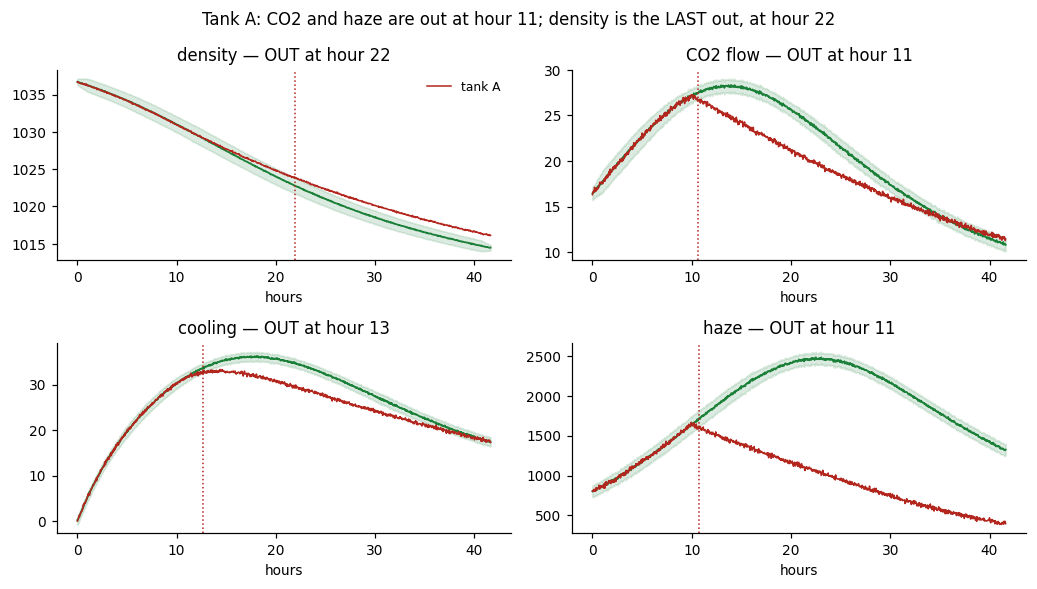

saved: generated_data/tank_A_yeast_fault.csv


In [11]:
dA = brew(yeast_drops_at=10.0, seed=201)
tcA, rcA = verdict_for(dA, "TANK A - yeast settles early")

fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.4))
for ax, c in zip(axes.ravel(), CHAN):
    t = dA["t"]
    ax.plot(t, prof[c], color=GOOD_C, lw=1.2)
    ax.fill_between(t, prof[c] - tol[c], prof[c] + tol[c], color=GOOD_C, alpha=.15)
    ax.plot(t, dA[c], color=BAD_C, lw=1.0, label="tank A")
    if tcA[c]["alarm"]:
        ax.axvline(tcA[c]["first"], color=BAD_C, ls=":", lw=1)
        ax.set_title(f"{NAME[c]} — OUT at hour {tcA[c]['first']:.0f}")
    else:
        ax.set_title(f"{NAME[c]} — inside the band")
    ax.set_xlabel("hours")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Tank A: CO2 and haze are out at hour 11; density is the LAST out, at hour 22")
fig.tight_layout(); plt.show()

# Save the complete fault record created here.
tank_frame(dA).to_csv(OUT / "tank_A_yeast_fault.csv", index=False)
print("saved:", OUT / "tank_A_yeast_fault.csv")



Three channels disagree with their rebuilds at once, so no single meter can be blamed:
**tank fault**, called at hour 11 — leaving 31 hours to act, and roughly 17 hours before
the density chart alone could be sure. What the checks cannot say is *why*. They report
“something is wrong,” never “the yeast settled.” That part is still a human's job.

## 5 · Situation two — the instrument goes wrong

This time the ferment is perfect — but from hour 10 the densitometer drifts, like a sensor
slowly getting dirty. Read on its own, its curve says the batch is falling behind. That is
the classic false alarm that gets good beer thrown away.

TANK B - densitometer drifts           -> INSTRUMENT FAULT (density)   golden-curve alarms: density@21h


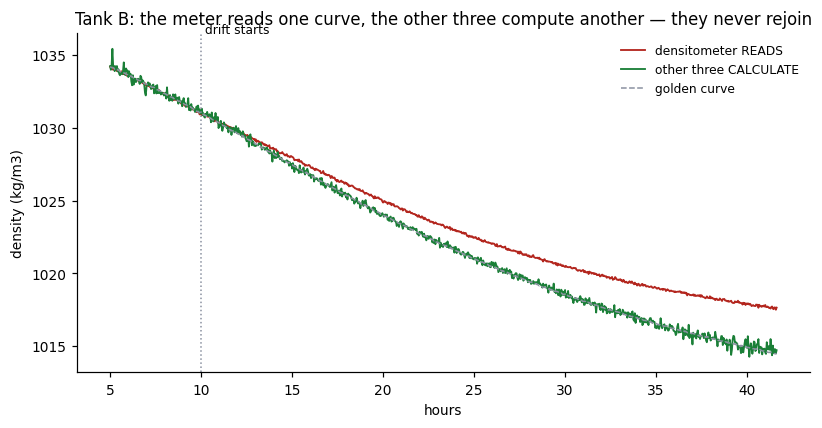

saved: generated_data/tank_B_density_meter_fault.csv


In [12]:
dB = brew(meter_drifts_at=10.0, seed=202)
tcB, rcB = verdict_for(dB, "TANK B - densitometer drifts")

(betaD, scD), inpD = full["rho"]
calc = _feats([np.asarray(dB[c])[T0:] for c in inpD]) @ betaD
t = dB["t"][T0:]
fig, ax = plt.subplots(figsize=(8.6, 4.0))
ax.plot(t, np.asarray(dB["rho"])[T0:], color=BAD_C, lw=1.2, label="densitometer READS")
ax.plot(t, calc, color=GOOD_C, lw=1.2, label="other three CALCULATE")
ax.plot(t, prof["rho"][T0:], color=GREY, lw=1.0, ls="--", label="golden curve")
ax.axvline(10, color=GREY, ls=":", lw=1); ax.text(10.2, ax.get_ylim()[1], "drift starts", fontsize=8)
ax.set_xlabel("hours"); ax.set_ylabel("density (kg/m3)")
ax.set_title("Tank B: the meter reads one curve, the other three compute another — they never rejoin")
ax.legend(frameon=False, fontsize=8); plt.show()

# Save the complete instrument-fault record created here.
tank_frame(dB).to_csv(OUT / "tank_B_density_meter_fault.csv", index=False)
print("saved:", OUT / "tank_B_density_meter_fault.csv")



## 6 · Audit every decision, right here

To close the loop, we build the audit table directly from the objects created above: which
channels left their golden curve, which disagreed with their cross-instrument
reconstruction, and what the final verdict was for each case.

The whole chain lives in this one notebook: **simulate → fit → test → diagnose → export**.

In [13]:
def audit_case(label, d):
    tc = time_check(prof, tol, d)
    rc = recon_check(full, d)
    verdict, who = diagnose(tc, rc, loo, d)
    return {
        "case": label,
        "verdict": verdict,
        "instrument": NAME[who] if who else "",
        "golden_curve_alarms": ", ".join(NAME[c] for c in CHAN if tc[c]["alarm"]) or "none",
        "reconstruction_alarms": ", ".join(NAME[c] for c in CHAN if rc[c]["alarm"]) or "none",
        "first_golden_alarm_h": min([tc[c]["first"] for c in CHAN if tc[c]["alarm"]], default=np.nan),
    }

audit = pd.DataFrame([
    audit_case("good tank 1", tanks[0]),
    audit_case("sixth unseen good tank", brew(seed=301, S0=95.2, X0=1.11)),
    audit_case("Tank A: yeast settles early", dA),
    audit_case("Tank B: densitometer drifts", dB),
])
display(audit)
audit.to_csv(OUT / "diagnosis_summary.csv", index=False)
print("saved:", OUT / "diagnosis_summary.csv")


,case,verdict,instrument,golden_curve_alarms,reconstruction_alarms,first_golden_alarm_h
0,good tank 1,all clear,,none,none,NaN
1,sixth unseen good tank,all clear,,none,none,NaN
2,Tank A: yeast settles early,tank fault,,"density, CO2 flow, cooling, haze","CO2 flow, cooling, haze",10.666667
3,Tank B: densitometer drifts,instrument fault,density,density,"density, CO2 flow, haze",20.916667


saved: generated_data/diagnosis_summary.csv


With the densitometer set aside, the remaining three instruments still agree among
themselves. One instrument out of step, three in harmony → **the densitometer is broken,
not the beer**. The batch is truly inside the release window; this is the alarm that saves
it.

## What part one shows — and what it never does

Two fitted checks, built only from the good batches, answer the two questions a cellar
actually asks — *will this be good beer?* and *is the instrument working?* — hours early,
with no chemistry and no one staring at a screen. But notice what never happened: the
checks never learned **what is inside the tank**. They cannot tell sugar from alcohol from
yeast; they say *wrong*, never *why*. Recovering the hidden quantities themselves is Part
two — the question the LeJEPA paper answers.

Everything above — the datasets, the extracted formulas, the diagnosis summary — was
created by this notebook in `generated_data/`. Delete that folder, run again from the top,
and it all comes back, identical.